# ipynb/multirm_r1.ipynb - MultiRM R1 实验 / MultiRM R1 experiment

## 项目背景 / Background
MultiRM R1 实验
MultiRM R1 experiment

## 功能模块 / Modules
- MultiRM 训练/推理实验报告
- (详见各代码单元 / see code cells)

## 输入 / Inputs
- 上一阶段产物(.npy/.pt/.csv/.json)/ prior-stage outputs
- 内嵌常量与参数 / inline constants and params

## 输出 / Outputs
- 图表(内联显示) / figures (inline)
- 中间变量 / intermediate variables
- 导出文件(.png/.pdf/.csv) / exported files

## 数据流 / Data Flow
1. 加载数据 / Load data
2. 运行分析 / Run analysis
3. 渲染图表 / Render figures
4. 导出 / Export

## 相关文件 / Related Files
- 调用 / Calls: train_human_multirm.py、inference_multirm_segmented.py
- 被调用 / Called by: 报告 / 论文 / report / paper

## 使用示例 / Usage Example
- 在 JupyterLab 中打开 / open in JupyterLab
- 逐单元运行 / run cells sequentially

## 作者 / Author
项目组 / Project Team

## 版本 / Version
1.0



In [10]:
# # 安装ggplot2包（仅首次需要，安装过一次就不用再运行）
# install.packages("ggnewscale")

# # # # 加载ggplot2包（每次打开R脚本/会话都需要运行）
# # # library(ggplot2)
# # install.packages("dplyr")


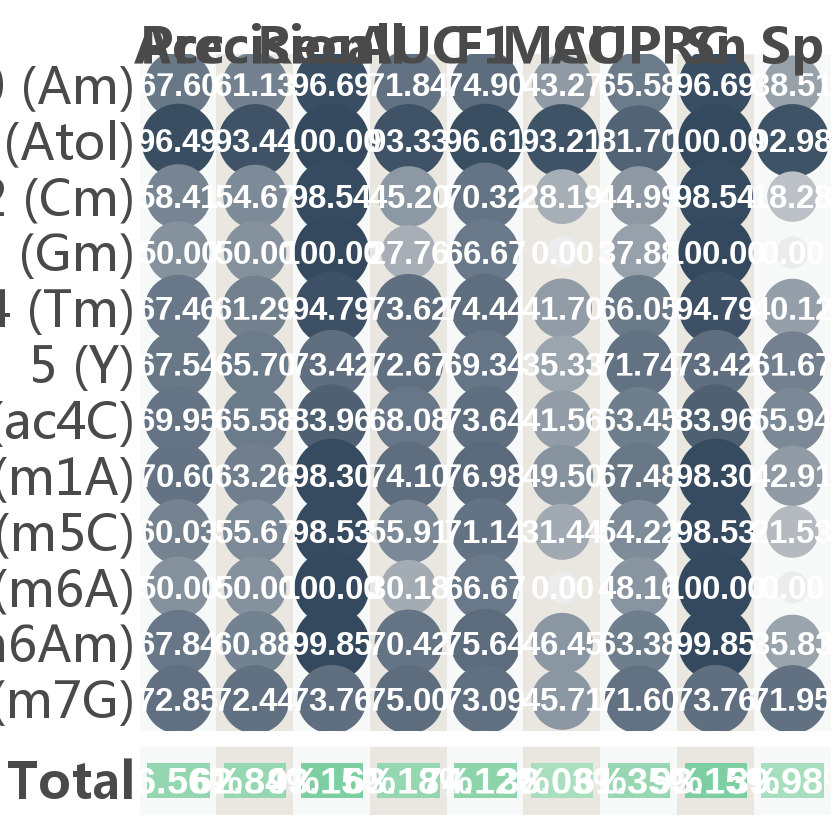

In [11]:
library(ggplot2)
library(dplyr)
library(tidyr)
library(patchwork)
library(ggnewscale)

# 2. 注册微软雅黑 (如路径不同请自行调整或使用系统默认)
tryCatch({
  font_add("YaHei", 
           regular = "/usr/share/fonts/truetype/myfonts/msyh.ttf", 
           bold = "/usr/share/fonts/truetype/myfonts/msyhbd.ttf")
  showtext_auto()
}, error = function(e) message("字体加载失败，使用默认字体"))

showtext_opts(dpi = 300)

# 1. 读取并准备数据
df <- read.csv("multirm_res.csv") 

# 模拟数据
# df <- data.frame(
#   Class = paste0("Class_", 1:10),
#   Acc = runif(10, 0.8, 0.95),
#   AUC = runif(10, 0.85, 0.98),
#   Precision = runif(10, 0.75, 0.9),
#   Recall = runif(10, 0.7, 0.9),
#   F1 = runif(10, 0.75, 0.92),
#   AUPRC = runif(10, 0.8, 0.96)
# )

metric_levels <- c("Acc","Precision","Recall", "AUC" ,  "F1","MCC", "AUPRC","Sn","Sp")
class_levels <- unique(df$Class)

plot_data <- df %>%
  select(Class, all_of(metric_levels)) %>%
  pivot_longer(cols = -Class, names_to = "Metric", values_to = "Value")

plot_data$Metric <- factor(plot_data$Metric, levels = metric_levels)
plot_data$Class <- factor(plot_data$Class, levels = rev(class_levels))

# 计算各 Metric 的平均值 (Total 栏)
metric_avg <- plot_data %>%
  group_by(Metric) %>%
  summarise(Avg_Value = mean(Value, na.rm = TRUE)) %>%
  mutate(Group = "Total")

# 2. 定义配色
bg_colors <- c("#F7F9F9", "#EAE7E1") 
bubble_palette <- c("#EAECEE", "#ABB2B9", "#85929E", "#5D6D7E", "#34495E")
total_palette <- c("#A9DFBF", "#7DCEA0")

# 3. 创建背景层数据
bg_data <- data.frame(
  Metric = factor(metric_levels, levels = metric_levels),
  xmin = seq_along(metric_levels) - 0.5,
  xmax = seq_along(metric_levels) + 0.5,
  bg_fill = rep(bg_colors, length.out = length(metric_levels))
)

# 4. 绘制左侧主图 (p1)
p1 <- ggplot() +
  geom_rect(data = bg_data, aes(xmin = xmin, xmax = xmax, ymin = -Inf, ymax = Inf, fill = bg_fill), 
            alpha = 1, show.legend = FALSE) +
  scale_fill_identity() + 
  
  geom_point(data = plot_data, aes(x = Metric, y = Class, size = Value, color = Value)) +
  
  # --- 修改点：label 乘以 100 并加上 % 符号 ---
  geom_text(data = plot_data, aes(x = Metric, y = Class, label = sprintf("%.2f", Value * 100)), 
            size = 2.8, color = "white", fontface = "bold") +
  
  scale_color_gradientn(colors = bubble_palette) +
  # 稍微调大 range 以适应更长的百分比文字
  scale_size_continuous(range = c(8, 20), limits = c(min(plot_data$Value)*0.8, 1)) +
  
  scale_x_discrete(position = "top", expand = expansion(mult = c(0, 0))) + 
  scale_y_discrete(expand = expansion(mult = c(0.05, 0.05))) +
  theme_minimal() +
  theme(
    text = element_text(family = "YaHei"),
    axis.text.x = element_text(size = 12, face = "bold", color = "#4A4A4A"),
    axis.text.y = element_text(size = 12, color = "#4A4A4A"),
    axis.title = element_blank(),
    panel.grid = element_blank(),
    legend.position = "none",
    plot.margin = margin(t = 10, r = 0, b = 10, l = 10)
  )

# 5. 绘制底部 Total 栏 (p2)
p2 <- ggplot() +
  geom_rect(data = bg_data, aes(xmin = xmin, xmax = xmax, ymin = -Inf, ymax = Inf, fill = bg_fill), 
            alpha = 1, show.legend = FALSE) +
  scale_fill_identity() +
  new_scale_fill() +
  geom_tile(data = metric_avg, aes(x = Metric, y = Group, fill = Avg_Value), 
            width = 0.8, height = 0.6) +
  
  # --- 修改点：汇总栏同样改为百分比 ---
  geom_text(data = metric_avg, aes(x = Metric, y = Group, label = sprintf("%.2f%%", Avg_Value * 100)), 
            color = "white", fontface = "bold", size = 3.2) +
            
  scale_fill_gradientn(colors = total_palette) +
  scale_x_discrete(expand = expansion(mult = c(0, 0))) +
  theme_minimal() +
  theme(
    text = element_text(family = "YaHei"),
    axis.text.x = element_blank(),
    axis.text.y = element_text(size = 12, face = "bold", color = "#4A4A4A"),
    axis.title = element_blank(),
    panel.grid = element_blank(),
    legend.position = "none",
    plot.margin = margin(t = 0, r = 0, b = 10, l = 10)
  )

# 6. 合并
final_plot <- p1 / p2 + plot_layout(heights = c(10, 1))



ggsave("final_percentage1.png", final_plot, width = 11, height = 12, dpi = 300)
print(final_plot)

In [12]:
# library(ggplot2)
# library(dplyr)
# library(tidyr)
# library(patchwork)
# library(scales)

# # 1. 定义 9 种莫兰迪色相 (保持高级灰调)
# morandi_hues <- c(
#   "Acc" = "#768D99", "Precision" = "#8A9A8A", "Recall" = "#B28F8F",
#   "AUC" = "#B6A691", "F1" = "#7E8B8C", "MCC" = "#938BA1",
#   "AUPRC" = "#AD8B7D", "Sn" = "#88A096", "Sp" = "#A8A085"
# )

# # 2. 数据准备与颜色映射
# metric_levels <- c("Acc","Precision","Recall", "AUC" ,  "F1","MCC", "AUPRC","Sn","Sp")
# class_levels <- unique(df$Class)

# plot_data <- df %>%
#   select(Class, all_of(metric_levels)) %>%
#   pivot_longer(cols = -Class, names_to = "Metric", values_to = "Value") %>%
#   mutate(
#     Metric = factor(Metric, levels = metric_levels),
#     Class = factor(Class, levels = rev(class_levels))
#   ) %>%
#   group_by(Metric) %>%
#   mutate(
#     # 颜色映射：从浅灰到各指标的主色相
#     point_color = col_numeric(
#       palette = c("#EAECEE", morandi_hues[as.character(Metric[1])]), 
#       domain = c(0.3, 1) # 这里的 domain 建议稍微大于实际最小值
#     )(Value),
#     # 核心修改：如果数值小于 0.6，文字用深灰色，否则用白色
#     # text_color = ifelse(Value < 0.6, "#4A4A4A", "white")
#     text_color = "#4A4A4A"
#   ) %>%
#   ungroup()

# # 汇总栏颜色
# metric_avg <- plot_data %>%
#   group_by(Metric) %>%
#   summarise(Avg_Value = mean(Value, na.rm = TRUE)) %>%
#   mutate(avg_color = morandi_hues[as.character(Metric)], Group = "Total")

# # 3. 绘制主图 (p1)
# p1 <- ggplot() +
#   # 背景层保持不变
#   geom_rect(data = bg_data, aes(xmin = xmin, xmax = xmax, ymin = -Inf, ymax = Inf, fill = bg_fill), 
#             alpha = 1, show.legend = FALSE) +
#   scale_fill_identity() + 
  
#   # 绘制圆圈
#   geom_point(data = plot_data, aes(x = Metric, y = Class, size = Value, color = point_color)) +
  
#   # 绘制文字：使用 identity 映射动态颜色
#   geom_text(data = plot_data, aes(x = Metric, y = Class, 
#                                  label = sprintf("%.2f", Value * 100),
#                                  color = text_color), 
#             size = 2.8, fontface = "bold", show.legend = FALSE) +
  
#   scale_color_identity() + # 关键：让 point_color 和 text_color 生效
  
#   # 核心修改：调大 range 的起始值（12），保证最小圆圈也能包住文字
#   scale_size_continuous(range = c(8, 22), limits = c(0.35, 1)) +
  
#   scale_x_discrete(position = "top", expand = expansion(mult = c(0, 0))) + 
#   scale_y_discrete(expand = expansion(mult = c(0.05, 0.05))) +
#   theme_minimal() +
#   theme(
#     axis.text.x = element_text(size = 11, face = "bold", color = "#4A4A4A"),
#     axis.text.y = element_text(size = 11, color = "#4A4A4A"),
#     axis.title = element_blank(),
#     panel.grid = element_blank(),
#     legend.position = "none"
#   )

# # 4. 汇总栏 (p2)
# p2 <- ggplot() +
#   geom_rect(data = bg_data, aes(xmin = xmin, xmax = xmax, ymin = -Inf, ymax = Inf, fill = bg_fill), 
#             alpha = 1, show.legend = FALSE) +
#   scale_fill_identity() +
#   geom_tile(data = metric_avg, aes(x = Metric, y = Group, fill = avg_color), 
#             width = 0.8, height = 0.6) +
#   geom_text(data = metric_avg, aes(x = Metric, y = Group, label = sprintf("%.2f%%", Avg_Value * 100)), 
#             color = "white", fontface = "bold", size = 3.2) +
#   scale_fill_identity() +
#   scale_x_discrete(expand = expansion(mult = c(0, 0))) +
#   theme_minimal() +
#   theme(
#     axis.text.x = element_blank(),
#     axis.text.y = element_text(size = 11, face = "bold", color = "#4A4A4A"),
#     axis.title = element_blank(),
#     panel.grid = element_blank()
#   )

# # 5. 合并
# final_plot <- p1 / p2 + plot_layout(heights = c(10, 1))
# ggsave("final_percentage2.png", final_plot, width = 11, height = 12, dpi = 300)
# print(final_plot)

In [13]:
# library(ggplot2)
# library(dplyr)
# library(tidyr)
# library(patchwork)
# library(scales)

# # 1. 定义 9 种莫兰迪色相
# morandi_hues <- c(
#   "Acc" = "#768D99", "Precision" = "#8A9A8A", "Recall" = "#B28F8F",
#   "AUC" = "#B6A691", "F1" = "#7E8B8C", "MCC" = "#938BA1",
#   "AUPRC" = "#AD8B7D", "Sn" = "#88A096", "Sp" = "#A8A085"
# )

# # 2. 数据准备
# metric_levels <- c("Acc","Precision","Recall", "AUC" ,  "F1","MCC", "AUPRC","Sn","Sp")
# class_levels <- unique(df$Class)

# plot_data <- df %>%
#   select(Class, all_of(metric_levels)) %>%
#   pivot_longer(cols = -Class, names_to = "Metric", values_to = "Value") %>%
#   mutate(
#     Metric = factor(Metric, levels = metric_levels),
#     Class = factor(Class, levels = rev(class_levels))
#   ) %>%
#   group_by(Metric) %>%
#   mutate(
#     point_color = col_numeric(
#       palette = c("#EAECEE", morandi_hues[as.character(Metric[1])]), 
#       domain = c(0.35, 1) 
#     )(Value),
#     text_color = "#4A4A4A" # 统一使用深灰字，也可根据上一版逻辑改回动态色
#   ) %>%
#   ungroup()

# metric_avg <- plot_data %>%
#   group_by(Metric) %>%
#   summarise(Avg_Value = mean(Value, na.rm = TRUE)) %>%
#   mutate(avg_color = morandi_hues[as.character(Metric)], Group = "Total")

# # 3. 绘制主图 (p1)
# p1 <- ggplot() +
#   geom_rect(data = bg_data, aes(xmin = xmin, xmax = xmax, ymin = -Inf, ymax = Inf, fill = bg_fill), 
#             alpha = 1, show.legend = FALSE) +
#   scale_fill_identity() + 
  
#   # 绘制圆圈
#   geom_point(data = plot_data, aes(x = Metric, y = Class, size = Value, color = point_color)) +
  
#   geom_text(data = plot_data, aes(x = Metric, y = Class, 
#                                  label = sprintf("%.2f", Value * 100),
#                                  color = text_color), 
#             size = 2.8, fontface = "bold", show.legend = FALSE) +
  
#   scale_color_identity() + 
  
#   # --- 核心修改：配置尺寸图例 ---
#   scale_size_continuous(
#     name = "Performance Value",
#     range = c(10, 22),       # 最小值设为10，确保38.80%也能包住文字
#     limits = c(0.35, 1), 
#     breaks = c(0.4, 0.6, 0.8, 1.0),
#     labels = c("40%", "60%", "80%", "100%")
#   ) +
  
#   # 强制给图例上色（使用莫兰迪中性色）
#   guides(
#     size = guide_legend(
#       override.aes = list(color = "#85929E"), # 使用中性莫兰迪灰
#       order = 1
#     )
#   ) +
  
#   scale_x_discrete(position = "top", expand = expansion(mult = c(0, 0))) + 
#   scale_y_discrete(expand = expansion(mult = c(0.05, 0.05))) +
#   theme_minimal() +
#   theme(
#     axis.text.x = element_text(size = 11, face = "bold", color = "#4A4A4A"),
#     axis.text.y = element_text(size = 11, color = "#4A4A4A"),
#     axis.title = element_blank(),
#     panel.grid = element_blank(),
#     # 图例样式微调
#     legend.position = "right",
#     legend.title = element_text(size = 10, face = "bold", color = "#4A4A4A"),
#     legend.text = element_text(size = 9, color = "#4A4A4A")
#   )

# # 4. 汇总栏 (p2)
# p2 <- ggplot() +
#   geom_rect(data = bg_data, aes(xmin = xmin, xmax = xmax, ymin = -Inf, ymax = Inf, fill = bg_fill), 
#             alpha = 1, show.legend = FALSE) +
#   scale_fill_identity() +
#   geom_tile(data = metric_avg, aes(x = Metric, y = Group, fill = avg_color), 
#             width = 0.8, height = 0.6) +
#   geom_text(data = metric_avg, aes(x = Metric, y = Group, label = sprintf("%.2f%%", Avg_Value * 100)), 
#             color = "white", fontface = "bold", size = 3.2) +
#   scale_fill_identity() +
#   scale_x_discrete(expand = expansion(mult = c(0, 0))) +
#   theme_minimal() +
#   theme(
#     axis.text.x = element_blank(),
#     axis.text.y = element_text(size = 11, face = "bold", color = "#4A4A4A"),
#     axis.title = element_blank(),
#     panel.grid = element_blank(),
#     legend.position = "none"
#   )

# # 5. 合并并收集图例
# final_plot <- p1 / p2 + 
#   plot_layout(heights = c(10, 1), guides = "collect") & 
#   theme(legend.justification = "bottom") # 让图例对齐上方

# # 保存
# ggsave("final_with_legend.png", final_plot, width = 12, height = 12, dpi = 300)
# print(final_plot)

In [14]:
# install.packages("ragg")
# library(ragg)

Warning message:
“There were 3 warnings in `mutate()`.
The first warning was:
ℹ In argument: `point_color = col_numeric(palette = c("#EAECEE",
  morandi_hues[as.character(Metric[1])]), ...`.
ℹ In group 4: `Metric = AUC`.
Caused by warning:
! Some values were outside the color scale and will be treated as NA
ℹ Run `dplyr::last_dplyr_warnings()` to see the 2 remaining warnings.”
Warning message:
“Removed 10 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 10 rows containing missing values or values outside the scale range
(`geom_point()`).”


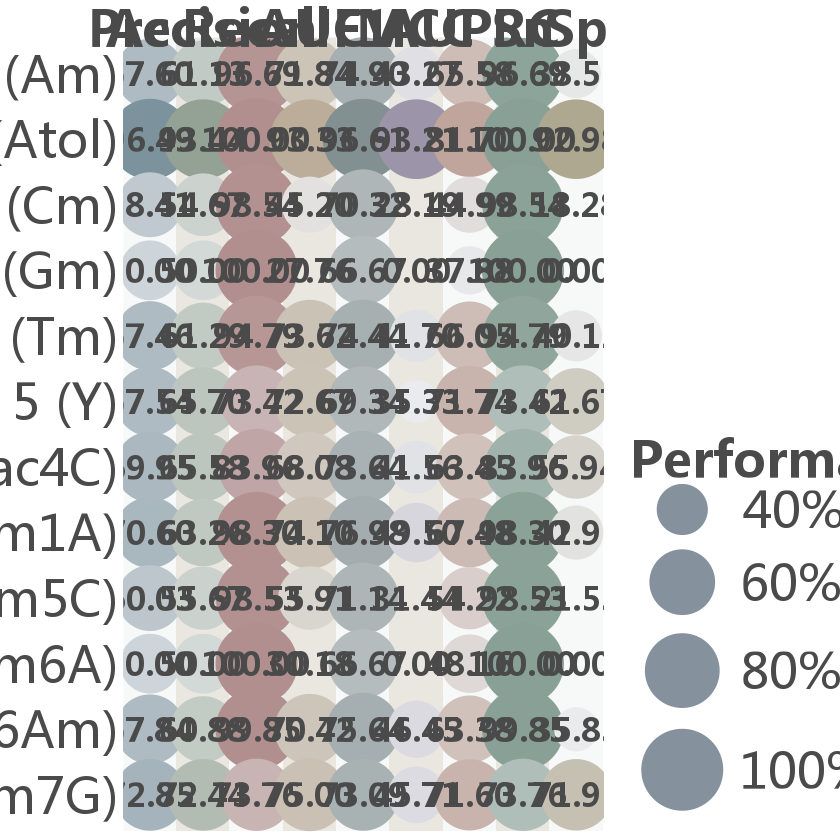

In [15]:
# 1. 安装并加载字体管理包
# if(!require(showtext)) install.packages("showtext")
library(showtext)

# 2. 注册微软雅黑 (确保名称与系统识别的一致)
# 如果你安装的是 .ttc，通常名字就是 "Microsoft YaHei"
font_add("YaHei", 
         regular = "/usr/share/fonts/truetype/myfonts/msyh.ttf", 
         bold = "/usr/share/fonts/truetype/myfonts/msyhbd.ttf")

# 2. 开启自动渲染
showtext_auto()

# 3. 这里的 dpi 建议与 ggsave 保持一致，防止预览和保存效果不一
showtext_opts(dpi = 300)

# --- 以下是你原本的代码，只需修改 theme 中的 family 参数 ---

library(ggplot2)
library(dplyr)
library(tidyr)
library(patchwork)
library(scales)

# 1. 定义 9 种莫兰迪色相
morandi_hues <- c(
  "Acc" = "#768D99", "Precision" = "#8A9A8A", "Recall" = "#B28F8F",
  "AUC" = "#B6A691", "F1" = "#7E8B8C", "MCC" = "#938BA1",
  "AUPRC" = "#AD8B7D", "Sn" = "#88A096", "Sp" = "#A8A085"
)

# 2. 数据准备
metric_levels <- c("Acc","Precision","Recall", "AUC" ,  "F1","MCC", "AUPRC","Sn","Sp")
class_levels <- unique(df$Class)

plot_data <- df %>%
  select(Class, all_of(metric_levels)) %>%
  pivot_longer(cols = -Class, names_to = "Metric", values_to = "Value") %>%
  mutate(
    Metric = factor(Metric, levels = metric_levels),
    Class = factor(Class, levels = rev(class_levels))
  ) %>%
  group_by(Metric) %>%
  mutate(
    point_color = col_numeric(
      palette = c("#EAECEE", morandi_hues[as.character(Metric[1])]), 
      domain = c(0.35, 1) 
    )(Value),
    text_color = "#4A4A4A" # 统一使用深灰字，也可根据上一版逻辑改回动态色
  ) %>%
  ungroup()

# 【删除了metric_avg汇总数据的计算，因为不需要Total栏了】

# 3. 绘制主图 (p1)
p1 <- ggplot() +
  geom_rect(data = bg_data, aes(xmin = xmin, xmax = xmax, ymin = -Inf, ymax = Inf, fill = bg_fill), 
            alpha = 1, show.legend = FALSE) +
  scale_fill_identity() + 
  
  # 绘制圆圈
  geom_point(data = plot_data, aes(x = Metric, y = Class, size = Value, color = point_color)) +
  
  geom_text(data = plot_data, aes(x = Metric, y = Class, 
                                 label = sprintf("%.2f", Value * 100),
                                 color = text_color), 
            size = 2.8, fontface = "bold", family = "YaHei", show.legend = FALSE) +
  
  scale_color_identity() + 
  
  # --- 核心修改：配置尺寸图例 ---
  scale_size_continuous(
    name = "Performance Value",
    range = c(10, 22),       # 最小值设为10，确保38.80%也能包住文字
    limits = c(0.35, 1), 
    breaks = c(0.4, 0.6, 0.8, 1.0),
    labels = c("40%", "60%", "80%", "100%")
  ) +
  
  # 强制给图例上色（使用莫兰迪中性色）
  guides(
    size = guide_legend(
      override.aes = list(color = "#85929E"), # 使用中性莫兰迪灰
      order = 1
    )
  ) +
  
  scale_x_discrete(position = "top", expand = expansion(mult = c(0, 0))) + 
  scale_y_discrete(expand = expansion(mult = c(0.05, 0.05))) +
  theme_minimal() +
  theme(
    # 修改：全局字体指定为 YaHei
    text = element_text(family = "YaHei"),
    axis.text.x = element_text(size = 12, face = "bold", color = "#4A4A4A"),
    axis.text.y = element_text(size = 12, color = "#4A4A4A"),
    axis.title = element_blank(),
    panel.grid = element_blank(), 
    legend.position = "right",
    legend.title = element_text(size = 12, face = "bold", color = "#4A4A4A"),
    legend.text = element_text(size = 12, color = "#4A4A4A")
  )

# 【直接删除了p2汇总栏的全部绘制代码】

# 5. 最终图表（无需合并，直接使用p1，保留图例配置）
final_plot <- p1 & 
  theme(legend.justification = "bottom") # 让图例对齐上方

# 保存（可根据需要微调宽高，因为移除了汇总栏，高度可适当减小）
ggsave("multirm_final_without_total.png", final_plot, width = 12, height = 10, dpi = 300)
print(final_plot)